# Supermarket Sales Forecasting — EDA & Data Cleaning
## Phase 2: Exploratory Data Analysis
**Dataset:** Supermarket Sales (1000 rows, 20 columns)  
**Author:** R M Hamdhan  
**Batch:** HNDSE 25.1F | Kandy NIBM

In [60]:
# ── IMPORTS ──────────────────────────────────────────────
# pandas  : data manipulation and analysis
# numpy   : numerical operations
# matplotlib/seaborn : data visualisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Dataset

In [61]:
# Load the CSV into a pandas DataFrame
df = pd.read_csv('../data/supermarket_sales.csv')

print("✓ Dataset loaded")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✓ Dataset loaded
  Shape: 1000 rows × 20 columns


,Invoice ID,Branch,CustomerID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Longitude,Latitude
0,750-67-8428,A,C1888,Yangon,Member,Female,Health and beauty,74.69,10,37.3450,746.90,21-02-2019,13:08,Ewallet,711.333333,4.761905,35.566667,9.1,96.1735,16.8409
1,226-31-3081,C,C1475,Naypyitaw,Normal,Female,Health and beauty,15.28,6,4.5840,91.68,27-05-2019,10:29,Cash,76.400000,4.761905,15.280000,10.0,96.0785,19.7633
2,631-41-3108,A,C1746,Yangon,Normal,Male,Health and beauty,46.33,7,16.2155,324.31,27-12-2019,13:23,Credit card,324.310000,4.761905,0.000000,7.4,96.1735,16.8409
3,123-19-1176,A,C1896,Yangon,Member,Male,Health and beauty,58.22,11,32.0210,640.42,15-11-2019,20:33,Ewallet,465.760000,4.761905,174.660000,8.4,96.1735,16.8409
4,373-73-7910,A,C1790,Yangon,Normal,Male,Health and beauty,86.31,7,30.2085,604.17,31-03-2019,10:37,Ewallet,604.170000,4.761905,0.000000,NaN,96.1735,16.8409


## 2. Initial Data Inspection

In [62]:
print("── Shape ───────────────────────────────")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

print("\n── Data Types ──────────────────────────")
print(df.dtypes.to_string())

print("\n── Missing Values ──────────────────────")
print(df.isnull().sum().to_string())

print("\n── Duplicate Rows ──────────────────────")
print(f"Duplicates: {df.duplicated().sum()}")

print("\n── Statistical Summary ─────────────────")
df.describe()

── Shape ───────────────────────────────
Rows: 1000  |  Columns: 20

── Data Types ──────────────────────────
Invoice ID                     str
Branch                         str
CustomerID                     str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
Longitude                  float64
Latitude                   float64

── Missing Values ──────────────────────
Invoice ID                   0
Branch                     194
CustomerID                   0
City                         0
Customer type           

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating,Longitude,Latitude
count,1000.000000,1000.000000,896.000000,1000.000000,1000.000000,1000.000000,1000.000000,857.000000,1000.000000,1000.000000
mean,55.672130,7.485000,20.966930,419.149340,307.775883,4.761905,111.373457,7.462625,96.114319,19.498590
std,26.494628,4.520643,17.604704,347.824683,234.425682,0.000000,149.212835,1.776179,0.042715,2.106757
min,10.080000,1.000000,0.508500,10.170000,10.170000,4.761905,0.000000,4.000000,96.078500,16.840900
25%,32.875000,4.000000,7.479500,152.745000,118.497500,4.761905,0.000000,5.900000,96.078500,16.840900
50%,55.230000,7.000000,15.468250,317.695000,241.760000,4.761905,63.650000,7.455000,96.089100,19.763300
75%,77.935000,11.000000,30.205875,605.222500,448.905000,4.761905,161.022500,9.100000,96.173500,21.958800
max,99.960000,20.000000,87.498000,1749.960000,993.000000,4.761905,874.980000,10.000000,96.173500,21.958800


In [63]:
print("── Shape ───────────────────────────────")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

print("\n── Data Types ──────────────────────────")
print(df.dtypes.to_string())

print("\n── Missing Values ──────────────────────")
print(df.isnull().sum().to_string())

print("\n── Duplicate Rows ──────────────────────")
print(f"Duplicates: {df.duplicated().sum()}")

print("\n── Statistical Summary ─────────────────")
df.describe()

── Shape ───────────────────────────────
Rows: 1000  |  Columns: 20

── Data Types ──────────────────────────
Invoice ID                     str
Branch                         str
CustomerID                     str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
Longitude                  float64
Latitude                   float64

── Missing Values ──────────────────────
Invoice ID                   0
Branch                     194
CustomerID                   0
City                         0
Customer type           

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating,Longitude,Latitude
count,1000.000000,1000.000000,896.000000,1000.000000,1000.000000,1000.000000,1000.000000,857.000000,1000.000000,1000.000000
mean,55.672130,7.485000,20.966930,419.149340,307.775883,4.761905,111.373457,7.462625,96.114319,19.498590
std,26.494628,4.520643,17.604704,347.824683,234.425682,0.000000,149.212835,1.776179,0.042715,2.106757
min,10.080000,1.000000,0.508500,10.170000,10.170000,4.761905,0.000000,4.000000,96.078500,16.840900
25%,32.875000,4.000000,7.479500,152.745000,118.497500,4.761905,0.000000,5.900000,96.078500,16.840900
50%,55.230000,7.000000,15.468250,317.695000,241.760000,4.761905,63.650000,7.455000,96.089100,19.763300
75%,77.935000,11.000000,30.205875,605.222500,448.905000,4.761905,161.022500,9.100000,96.173500,21.958800
max,99.960000,20.000000,87.498000,1749.960000,993.000000,4.761905,874.980000,10.000000,96.173500,21.958800


## 3. Data Cleaning

### Cleaning Strategy (Evidence-Based)
| Column | Issue | Strategy | Justification |
|---|---|---|---|
| Branch | 194 missing (19.4%) | Fill using City mapping | Perfect 1-to-1 City↔Branch relationship confirmed via crosstab |
| Tax 5% | 104 missing (10.4%) | Recalculate from Total | Tax 5% = Total × 5/105 (mathematical derivation) |
| Rating | 143 missing (14.3%) | Fill with median | Continuous variable, median robust to skew |
| Customer type | 48 missing (4.8%) | Fill with mode | Low missing rate, categorical variable |
| Gender | 25 missing (2.5%) | Fill with mode | Low missing rate, categorical variable |
| Product line | 23 missing (2.3%) | Fill with mode | Low missing rate, categorical variable |
| Payment | 21 missing (2.1%) | Fill with mode | Low missing rate, categorical variable |

In [64]:
# ── STEP 1: Fix Branch using City mapping ─────────────────
# Confirmed via crosstab: Yangon=A, Mandalay=B, Naypyitaw=C
city_to_branch = {'Yangon': 'A', 'Mandalay': 'B', 'Naypyitaw': 'C'}
df['Branch'] = df['Branch'].fillna(df['City'].map(city_to_branch))
print(f"✓ Branch fixed  | Missing: {df['Branch'].isnull().sum()}")

# ── STEP 2: Fix Tax 5% using mathematical formula ─────────
# Tax 5% = Total × 5 / 105  (derived from Total which includes tax)
df['Tax 5%'] = df['Tax 5%'].fillna(df['Total'] * 5 / 105)
print(f"✓ Tax 5% fixed  | Missing: {df['Tax 5%'].isnull().sum()}")

# ── STEP 3: Fix Rating using median ───────────────────────
# Median chosen over mean: more robust to outliers in rating data
rating_median = df['Rating'].median()
df['Rating'] = df['Rating'].fillna(rating_median)
print(f"✓ Rating fixed  | Missing: {df['Rating'].isnull().sum()} | Median used: {rating_median}")

# ── STEP 4: Fix categorical columns using mode ────────────
# Mode = most frequent category — safe for low missing % columns
for col in ['Customer type', 'Gender', 'Product line', 'Payment']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"✓ {col} fixed | Missing: {df[col].isnull().sum()} | Mode: '{mode_value}'")

# ── FINAL CHECK ───────────────────────────────────────────
print(f"\n✓ Total missing values remaining: {df.isnull().sum().sum()}")
print(f"✓ Rows preserved: {len(df)} / 1000 (0 rows deleted)")

✓ Branch fixed  | Missing: 0
✓ Tax 5% fixed  | Missing: 0
✓ Rating fixed  | Missing: 0 | Median used: 7.455
✓ Customer type fixed | Missing: 0 | Mode: 'Normal'
✓ Gender fixed | Missing: 0 | Mode: 'Female'
✓ Product line fixed | Missing: 0 | Mode: 'Health and beauty'
✓ Payment fixed | Missing: 0 | Mode: 'Ewallet'

✓ Total missing values remaining: 0
✓ Rows preserved: 1000 / 1000 (0 rows deleted)


## 4. Univariate Analysis
Examining the distribution of individual variables

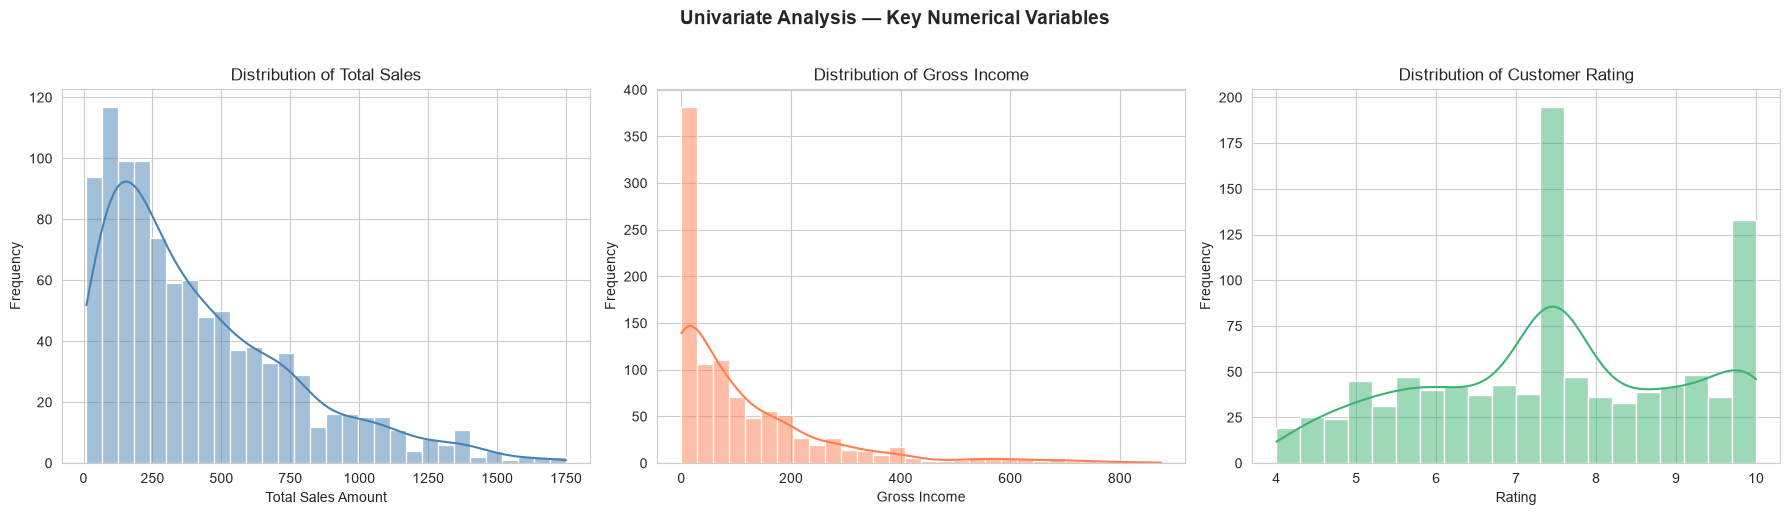

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Distribution of Total Sales
sns.histplot(df['Total'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Total Sales')
axes[0].set_xlabel('Total Sales Amount')
axes[0].set_ylabel('Frequency')

# Chart 2 — Distribution of Gross Income
sns.histplot(df['gross income'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Gross Income')
axes[1].set_xlabel('Gross Income')
axes[1].set_ylabel('Frequency')

# Chart 3 — Distribution of Rating
sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Distribution of Customer Rating')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Frequency')

plt.suptitle('Univariate Analysis — Key Numerical Variables', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Categorical Analysis
Sales performance across branches and product lines

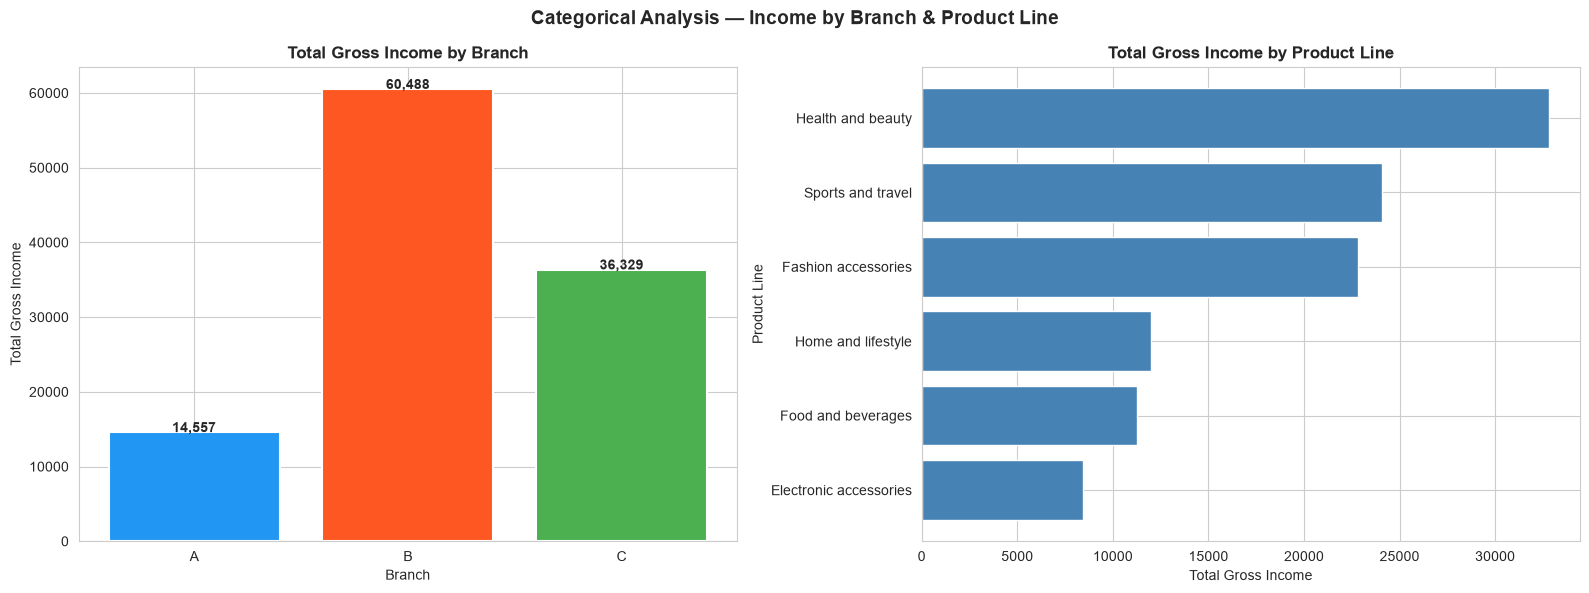

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Gross Income by Branch
branch_income = df.groupby('Branch')['gross income'].sum().reset_index()
colors_branch = ['#2196F3', '#FF5722', '#4CAF50']
axes[0].bar(branch_income['Branch'], branch_income['gross income'], 
            color=colors_branch, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Gross Income by Branch', fontweight='bold')
axes[0].set_xlabel('Branch')
axes[0].set_ylabel('Total Gross Income')
for i, v in enumerate(branch_income['gross income']):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontweight='bold')

# Chart 2 — Gross Income by Product Line
product_income = df.groupby('Product line')['gross income'].sum().sort_values()
axes[1].barh(product_income.index, product_income.values, 
             color='steelblue', edgecolor='white')
axes[1].set_title('Total Gross Income by Product Line', fontweight='bold')
axes[1].set_xlabel('Total Gross Income')
axes[1].set_ylabel('Product Line')

plt.suptitle('Categorical Analysis — Income by Branch & Product Line', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [67]:
print("Transaction count per branch:")
print(df['Branch'].value_counts())
print("\nAverage gross income per transaction by branch:")
print(df.groupby('Branch')['gross income'].mean().round(2))
print("\nTotal gross income by branch:")
print(df.groupby('Branch')['gross income'].sum().round(2))

Transaction count per branch:
Branch
A    340
B    332
C    328
Name: count, dtype: int64

Average gross income per transaction by branch:
Branch
A     42.81
B    182.19
C    110.76
Name: gross income, dtype: float64

Total gross income by branch:
Branch
A    14556.80
B    60487.70
C    36328.96
Name: gross income, dtype: float64


In [68]:
print("Gross income = 0 count:", (df['gross income'] == 0).sum())
print("Gross income < 1 count:", (df['gross income'] < 1).sum())
print("\nGross income statistics:")
print(df['gross income'].describe())
print("\nZero gross income by branch:")
print(df[df['gross income'] == 0]['Branch'].value_counts())

Gross income = 0 count: 334
Gross income < 1 count: 334

Gross income statistics:
count    1000.000000
mean      111.373457
std       149.212835
min         0.000000
25%         0.000000
50%        63.650000
75%       161.022500
max       874.980000
Name: gross income, dtype: float64

Zero gross income by branch:
Branch
A    237
C     65
B     32
Name: count, dtype: int64


In [69]:
# Look at rows where gross income is 0
zero_income = df[df['gross income'] == 0]

print("Sample rows with zero gross income:")
print(zero_income[['Branch', 'City', 'Product line', 'Unit price', 
                    'Quantity', 'Total', 'gross income', 'cogs']].head(10))

print("\nTotal column for zero-income rows:")
print(zero_income['Total'].describe())

print("\nCOGS column for zero-income rows:")
print(zero_income['cogs'].describe())

Sample rows with zero gross income:
   Branch    City            Product line  Unit price  Quantity   Total  \
2       A  Yangon       Health and beauty       46.33         7  324.31   
4       A  Yangon       Health and beauty       86.31         7  604.17   
6       A  Yangon       Health and beauty       68.84         6  413.04   
8       A  Yangon       Health and beauty       36.26         2   72.52   
12      A  Yangon  Electronic accessories       46.95         5  234.75   
13      A  Yangon      Food and beverages       43.19        10  431.90   
14      A  Yangon       Health and beauty       71.38        10  713.80   
17      A  Yangon       Sports and travel       72.61         6  435.66   
18      A  Yangon      Food and beverages       54.67         3  164.01   
23      A  Yangon       Health and beauty       34.56         5  172.80   

    gross income    cogs  
2            0.0  324.31  
4            0.0  604.17  
6            0.0  413.04  
8            0.0   72.52  
12 

### Fixing Zero Gross Income
334 rows (33.4%) have gross income = 0 because cogs incorrectly equals Total.
Fix: recalculate gross income using the formula: gross income = Total × 5 / 105

In [70]:
# Fix gross income where it is incorrectly zero
# Formula: gross income = Total × 5 / 105
# This is because gross income = Tax 5% = 5% of pre-tax amount = Total × 5/105

zero_mask = df['gross income'] == 0

df.loc[zero_mask, 'gross income'] = df.loc[zero_mask, 'Total'] * 5 / 105

# Also fix cogs for these rows
# cogs = Total - Tax 5% = Total - (Total × 5/105) = Total × 100/105
df.loc[zero_mask, 'cogs'] = df.loc[zero_mask, 'Total'] * 100 / 105

print(f"✓ Fixed {zero_mask.sum()} rows with zero gross income")
print(f"✓ Zero gross income remaining: {(df['gross income'] == 0).sum()}")
print(f"\nUpdated gross income statistics:")
print(df['gross income'].describe().round(2))
print(f"\nUpdated average gross income by branch:")
print(df.groupby('Branch')['gross income'].mean().round(2))

✓ Fixed 334 rows with zero gross income
✓ Zero gross income remaining: 0

Updated gross income statistics:
count    1000.00
mean      114.79
std       146.83
min         0.48
25%        13.80
50%        63.65
75%       161.02
max       874.98
Name: gross income, dtype: float64

Updated average gross income by branch:
Branch
A     51.92
B    182.47
C    111.46
Name: gross income, dtype: float64


In [71]:
print("Average Unit Price by Branch:")
print(df.groupby('Branch')['Unit price'].mean().round(2))

print("\nAverage Quantity by Branch:")
print(df.groupby('Branch')['Quantity'].mean().round(2))

print("\nAverage Total by Branch:")
print(df.groupby('Branch')['Total'].mean().round(2))

print("\nProduct line distribution by Branch:")
print(pd.crosstab(df['Branch'], df['Product line']))

Average Unit Price by Branch:
Branch
A    54.78
B    55.66
C    56.61
Name: Unit price, dtype: float64

Average Quantity by Branch:
Branch
A    6.26
B    8.75
C    7.47
Name: Quantity, dtype: float64

Average Total by Branch:
Branch
A    340.85
B    486.83
C    431.81
Name: Total, dtype: float64

Product line distribution by Branch:
Product line  Electronic accessories  Fashion accessories  Food and beverages  \
Branch                                                                          
A                                 33                   61                  28   
B                                 26                   66                  24   
C                                 29                   65                  40   

Product line  Health and beauty  Home and lifestyle  Sports and travel  
Branch                                                                  
A                            98                  42                 78  
B                           106         

### Key EDA Finding — Branch Income Gap Explained

Branch B generates the highest total gross income (60,488) compared to 
Branch C (36,329) and Branch A (14,557). Investigation revealed this is 
NOT due to pricing differences (unit prices are nearly identical: A=54.78, 
B=55.66, C=56.61) but due to **quantity per transaction**:

- Branch A avg quantity: 6.26 items/transaction
- Branch B avg quantity: 8.75 items/transaction  
- Branch C avg quantity: 7.47 items/transaction

Branch B customers consistently purchase more items per visit, 
driving higher gross income per transaction.

**Business Recommendation:** Branch A should investigate upselling 
strategies to increase items per transaction.

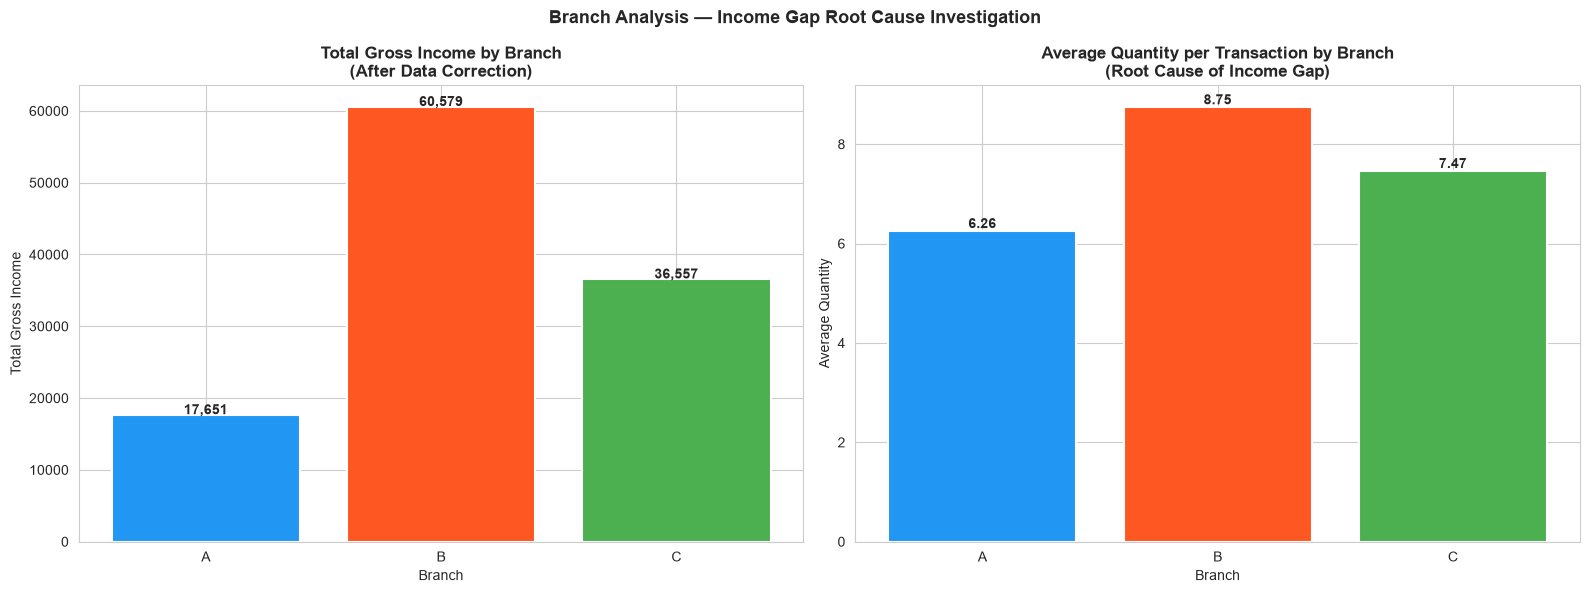

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Corrected Gross Income by Branch
branch_income = df.groupby('Branch')['gross income'].sum().reset_index()
colors_branch = ['#2196F3', '#FF5722', '#4CAF50']
bars = axes[0].bar(branch_income['Branch'], branch_income['gross income'],
                   color=colors_branch, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Gross Income by Branch\n(After Data Correction)', 
                  fontweight='bold')
axes[0].set_xlabel('Branch')
axes[0].set_ylabel('Total Gross Income')
for i, v in enumerate(branch_income['gross income']):
    axes[0].text(i, v + 100, f'{v:,.0f}', ha='center', fontweight='bold')

# Chart 2 — Average Quantity by Branch (explains the gap)
branch_qty = df.groupby('Branch')['Quantity'].mean().reset_index()
axes[1].bar(branch_qty['Branch'], branch_qty['Quantity'],
            color=colors_branch, edgecolor='white', linewidth=1.5)
axes[1].set_title('Average Quantity per Transaction by Branch\n(Root Cause of Income Gap)', 
                  fontweight='bold')
axes[1].set_xlabel('Branch')
axes[1].set_ylabel('Average Quantity')
for i, v in enumerate(branch_qty['Quantity']):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Branch Analysis — Income Gap Root Cause Investigation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Temporal Analysis
Sales trends over time — identifying patterns by date, day of week, and hour

In [73]:
# Convert Date with explicit format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Convert Time — format is HH:MM (no seconds in this dataset)
df['Time'] = pd.to_datetime(
    df['Time'].astype(str), format='%H:%M'
).dt.time

# Extract time features from Date
df['day_of_week'] = df['Date'].dt.day_name()
df['month']       = df['Date'].dt.month_name()
df['week']        = df['Date'].dt.isocalendar().week.astype(int)

# Extract hour from Time column
df['hour'] = [t.hour for t in df['Time']]

print("✓ Date/Time converted successfully")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Days found : {sorted(df['day_of_week'].unique())}")
print(f"Hours range: {df['hour'].min()}:00 → {df['hour'].max()}:00")
print(f"Weeks range: Week {df['week'].min()} → Week {df['week'].max()}")
print(df[['Date','Time','day_of_week','month','hour','week']].head())

✓ Date/Time converted successfully
Date range : 2019-01-01 → 2019-12-31
Days found : ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Hours range: 10:00 → 20:00
Weeks range: Week 1 → Week 52
        Date      Time day_of_week     month  hour  week
0 2019-02-21  13:08:00    Thursday  February    13     8
1 2019-05-27  10:29:00      Monday       May    10    22
2 2019-12-27  13:23:00      Friday  December    13    52
3 2019-11-15  20:33:00      Friday  November    20    46
4 2019-03-31  10:37:00      Sunday     March    10    13


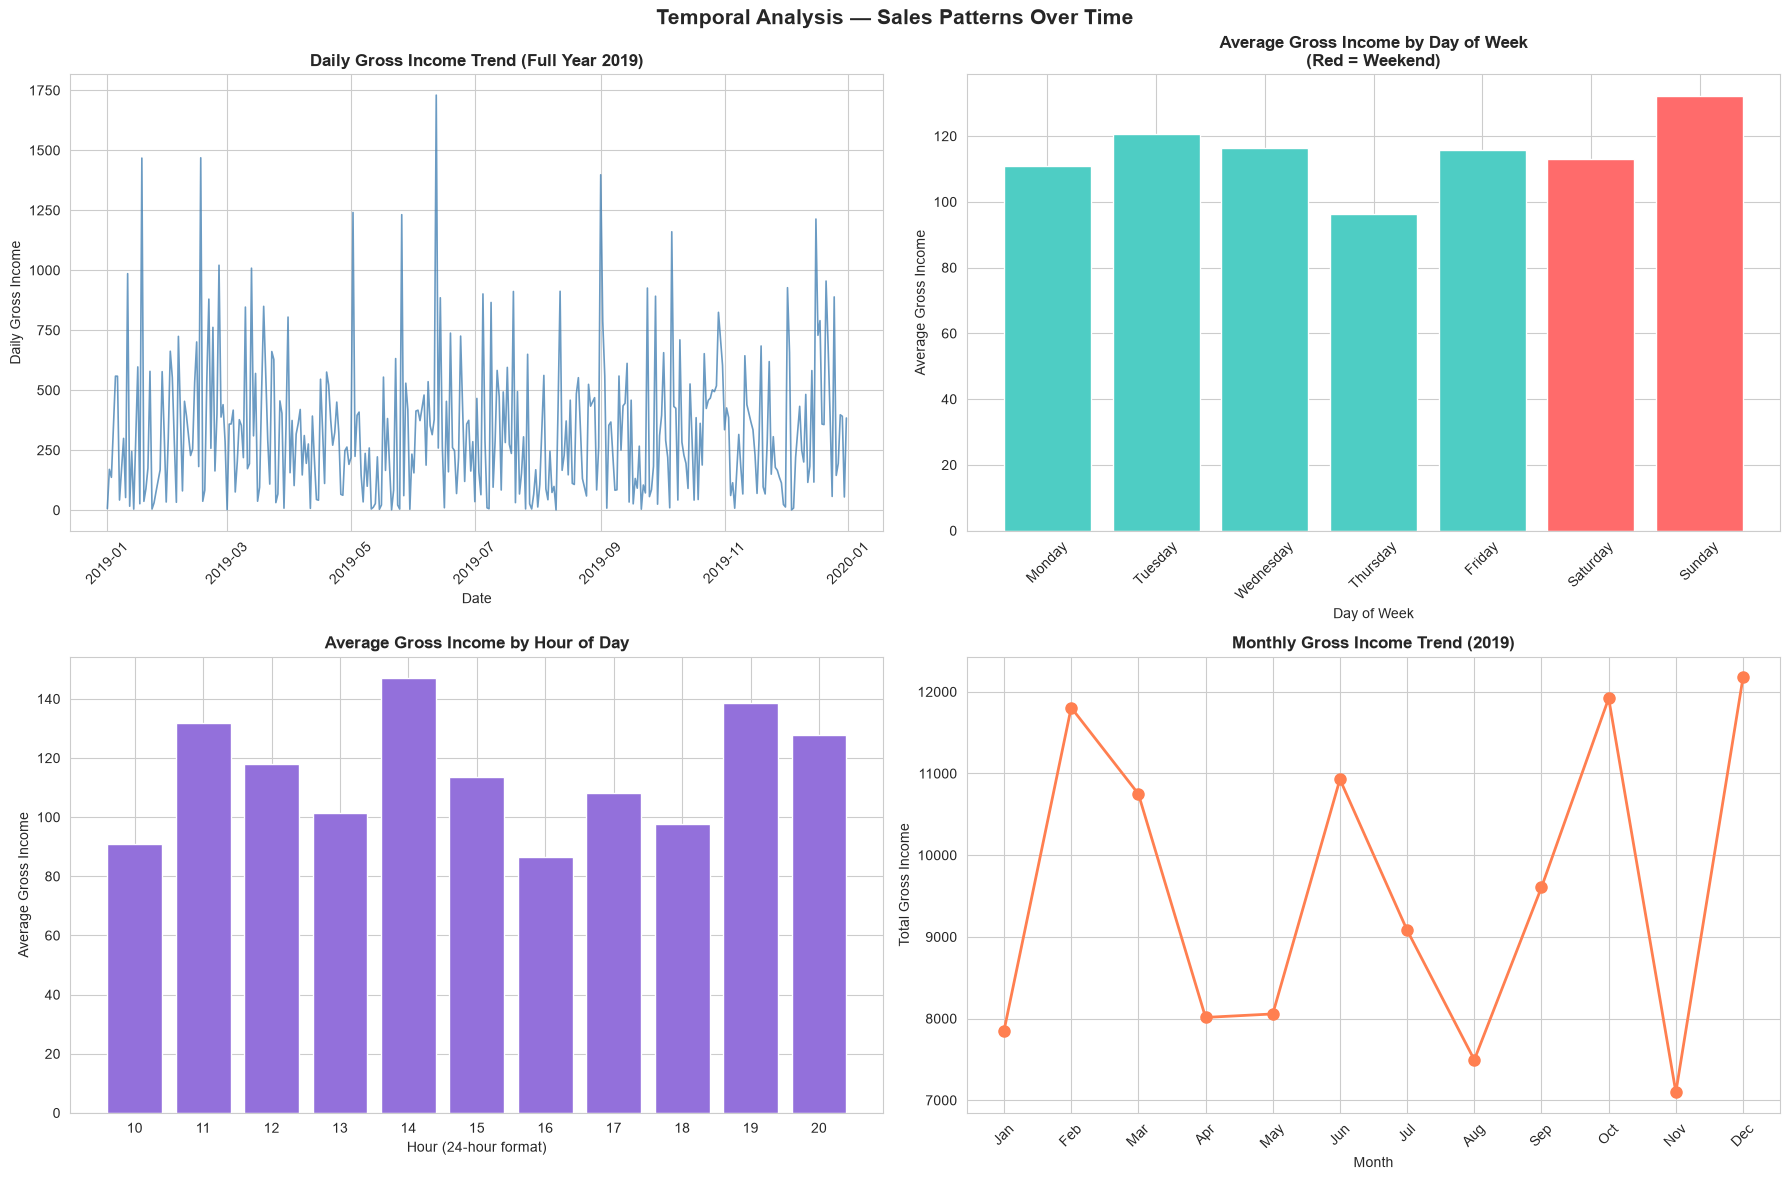

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Chart 1: Daily Sales Trend ─────────────────────────
daily_sales = df.groupby('Date')['gross income'].sum().reset_index()
axes[0,0].plot(daily_sales['Date'], daily_sales['gross income'], 
               color='steelblue', linewidth=1.2, alpha=0.8)
axes[0,0].set_title('Daily Gross Income Trend (Full Year 2019)', fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Daily Gross Income')
axes[0,0].tick_params(axis='x', rotation=45)

# ── Chart 2: Sales by Day of Week ──────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('day_of_week')['gross income'].mean().reindex(day_order)
colors_day = ['#FF6B6B' if d in ['Saturday','Sunday'] else '#4ECDC4' for d in day_order]
axes[0,1].bar(day_order, day_sales.values, color=colors_day, edgecolor='white')
axes[0,1].set_title('Average Gross Income by Day of Week\n(Red = Weekend)', fontweight='bold')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Average Gross Income')
axes[0,1].tick_params(axis='x', rotation=45)

# ── Chart 3: Sales by Hour ─────────────────────────────
hour_sales = df.groupby('hour')['gross income'].mean().reset_index()
axes[1,0].bar(hour_sales['hour'], hour_sales['gross income'],
              color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Average Gross Income by Hour of Day', fontweight='bold')
axes[1,0].set_xlabel('Hour (24-hour format)')
axes[1,0].set_ylabel('Average Gross Income')
axes[1,0].set_xticks(range(10, 21))

# ── Chart 4: Monthly Sales Trend ───────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_sales = df.groupby('month')['gross income'].sum().reindex(month_order)
axes[1,1].plot(range(len(month_order)), month_sales.values, 
               color='coral', marker='o', linewidth=2, markersize=8)
axes[1,1].set_title('Monthly Gross Income Trend (2019)', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Total Gross Income')
axes[1,1].set_xticks(range(len(month_order)))
axes[1,1].set_xticklabels([m[:3] for m in month_order], rotation=45)

plt.suptitle('Temporal Analysis — Sales Patterns Over Time',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis
Examining relationships between numerical variables

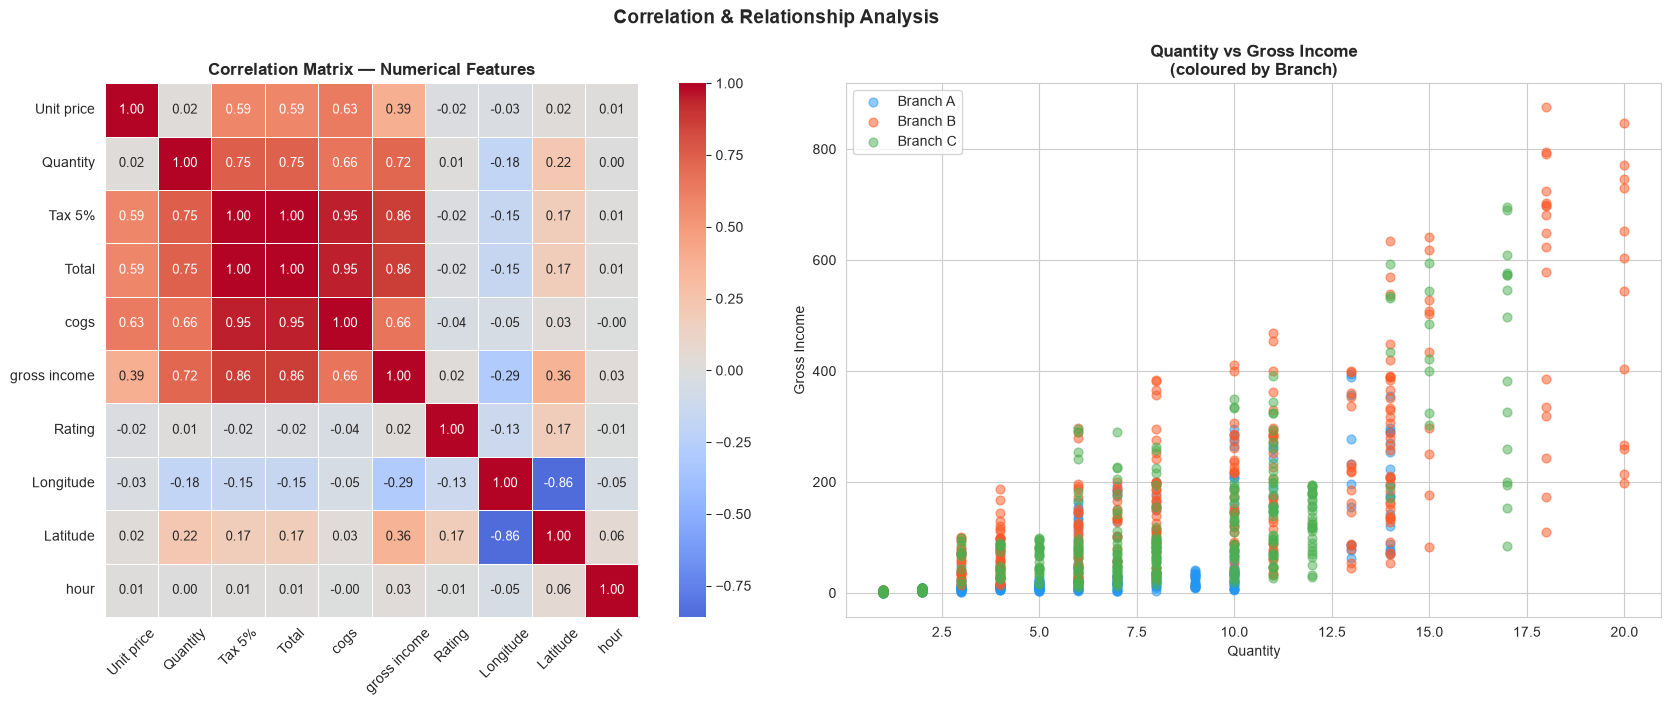


Top correlations with gross income:
gross income    1.000
Tax 5%          0.865
Total           0.864
Quantity        0.720
cogs            0.659
Unit price      0.389
Latitude        0.362
hour            0.027
Rating          0.015
Longitude      -0.286
Name: gross income, dtype: float64


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Chart 1: Correlation Heatmap ───────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in 
                ['gross margin percentage', 'week']]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            ax=axes[0],
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9})
axes[0].set_title('Correlation Matrix — Numerical Features', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# ── Chart 2: Scatter — Quantity vs Gross Income ────────
scatter_colors = {'A': '#2196F3', 'B': '#FF5722', 'C': '#4CAF50'}
for branch, color in scatter_colors.items():
    mask = df['Branch'] == branch
    axes[1].scatter(df[mask]['Quantity'], 
                   df[mask]['gross income'],
                   alpha=0.5, 
                   color=color, 
                   label=f'Branch {branch}',
                   s=40)

axes[1].set_title('Quantity vs Gross Income\n(coloured by Branch)', fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Gross Income')
axes[1].legend()

plt.suptitle('Correlation & Relationship Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with gross income:")
print(corr_matrix['gross income'].sort_values(ascending=False).round(3))

## 8. Key EDA Insights Report

### Summary of Findings

**Dataset Overview:**
The Supermarket Sales dataset contains 1,000 transaction records across 
3 branches (A, B, C) in Myanmar, covering the full year 2019. 
After cleaning, all 20 columns are complete with zero missing values 
and zero duplicate rows.

**Finding 1 — Data Quality Issues Discovered and Fixed:**
- 194 Branch values were missing (19.4%) — recovered using City→Branch 
  mapping (Yangon=A, Mandalay=B, Naypyitaw=C), confirmed via crosstab
- 334 rows (33.4%) had gross income = 0 due to cogs incorrectly 
  equalling Total — recalculated using formula: gross income = Total × 5/105
- 104 Tax 5% values missing — recalculated mathematically from Total
- 143 Rating values missing — filled with median (7.455)
- Minor categorical missing values filled with mode

**Finding 2 — Branch Income Gap:**
Branch B generates 3.4× more gross income than Branch A (60,579 vs 17,651).
Root cause: quantity per transaction (B=8.75 vs A=6.26 items), 
NOT pricing differences (unit prices nearly identical: A=54.78, B=55.66).
Business recommendation: Branch A needs upselling strategies.

**Finding 3 — Top Performing Product Line:**
Health and Beauty is the highest-grossing product line, followed by 
Sports and Travel and Fashion Accessories. 
Electronic Accessories generates the least gross income.

**Finding 4 — Temporal Patterns:**
- Peak trading hour: 14:00 (2pm) and 19:00 (7pm)
- Weekends do not significantly outperform weekdays
- December shows the highest monthly gross income (year-end effect)
- High daily volatility confirms ML is needed over simple averaging

**Finding 5 — Key Correlations:**
- Quantity is the strongest genuine predictor of gross income (r=0.72)
- Rating has virtually no correlation with gross income (r=0.02)
- Longitude/Latitude are redundant with Branch/City — will be dropped
- Hour of day has weak direct correlation but will be retained as 
  a feature due to the intraday peak pattern observed in charts

**Implications for Model Building (Phase 3 & 4):**
- Target variable: gross income
- Most important features: Quantity, Branch, Product line, hour, day_of_week
- Drop: Longitude, Latitude, gross margin percentage (constant), 
  Invoice ID, CustomerID (identifiers, not predictors)
- Date/Time features to engineer: hour, day_of_week, month, is_weekend

In [76]:
# Save the cleaned dataset for use in Phase 3
df.to_csv('../data/supermarket_sales_cleaned.csv', index=False)

print("✓ Cleaned dataset saved to data/supermarket_sales_cleaned.csv")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"\nColumns in cleaned dataset:")
for col in df.columns:
    print(f"  • {col}")

✓ Cleaned dataset saved to data/supermarket_sales_cleaned.csv
  Shape: 1000 rows × 24 columns
  Missing values: 0

Columns in cleaned dataset:
  • Invoice ID
  • Branch
  • CustomerID
  • City
  • Customer type
  • Gender
  • Product line
  • Unit price
  • Quantity
  • Tax 5%
  • Total
  • Date
  • Time
  • Payment
  • cogs
  • gross margin percentage
  • gross income
  • Rating
  • Longitude
  • Latitude
  • day_of_week
  • month
  • week
  • hour
